In [1]:
import numpy as np
from tensorflow.keras.layers import Input, Dense, Dropout, LayerNormalization
from tensorflow.keras.layers import MultiHeadAttention, GlobalAveragePooling1D
from tensorflow.keras.models import Model
from sklearn.metrics import classification_report

D:\Anaconda\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
X_train = np.load("D:/PomegranateGuard/features/train_features.npy")
X_val   = np.load("D:/PomegranateGuard/features/val_features.npy")
X_test  = np.load("D:/PomegranateGuard/features/test_features.npy")

y_train = np.load("D:/PomegranateGuard/dataset/y_train.npy")
y_val   = np.load("D:/PomegranateGuard/dataset/y_val.npy")
y_test  = np.load("D:/PomegranateGuard/dataset/y_test.npy")

print("Train features:", X_train.shape)

Train features: (3938, 128)


In [3]:
X_train = X_train.reshape(X_train.shape[0], 8, 16)
X_val   = X_val.reshape(X_val.shape[0], 8, 16)
X_test  = X_test.reshape(X_test.shape[0], 8, 16)

num_classes = 4

In [4]:
inputs = Input(shape=(8,16))

attention = MultiHeadAttention(
    num_heads=4,
    key_dim=16
)(inputs, inputs)

x = LayerNormalization()(attention + inputs)

x = GlobalAveragePooling1D()(x)

x = Dense(64, activation='relu')(x)
x = Dropout(0.4)(x)

outputs = Dense(4, activation='softmax')(x)

model = Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 8, 16)             │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multi_head_attention          │ (None, 8, 16)             │           4,304 │ input_layer[0][0],         │
│ (MultiHeadAttention)          │                           │                 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add (Add)                     │ (None, 8, 16)             │               0 │ multi_head_attention[0][0… │
│                               │                           │                 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization           │ (None, 8, 16)             │              32 │ add[0][0]                  │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_average_pooling1d      │ (None, 16)                │               0 │ layer_normalization[0][0]  │
│ (GlobalAveragePooling1D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 64)                │           1,088 │ global_average_pooling1d[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 64)                │               0 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 4)                 │             260 │ dropout_1[0][0]            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 5,684 (22.20 KB)

 Trainable params: 5,684 (22.20 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 15s 28ms/step - accuracy: 0.9048 - loss: 0.4630 - val_accuracy: 0.9704 - val_loss: 0.0947
Epoch 2/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9921 - loss: 0.0426 - val_accuracy: 0.9799 - val_loss: 0.0758
Epoch 3/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9939 - loss: 0.0239 - val_accuracy: 0.9810 - val_loss: 0.0858
Epoch 4/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9934 - loss: 0.0214 - val_accuracy: 0.9822 - val_loss: 0.0851
Epoch 5/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9967 - loss: 0.0136 - val_accuracy: 0.9810 - val_loss: 0.0889
Epoch 6/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9952 - loss: 0.0145 - val_accuracy: 0.9834 - val_loss: 0.0871
Epoch 7/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9962 - loss: 0.0102 - val_accuracy: 0.9787 - val_loss: 0.0929
Epoch 8/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9977 - loss: 0.0090 - val_acc

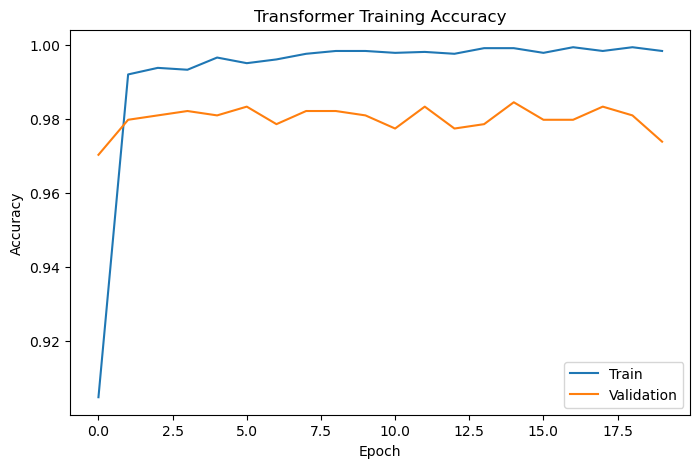

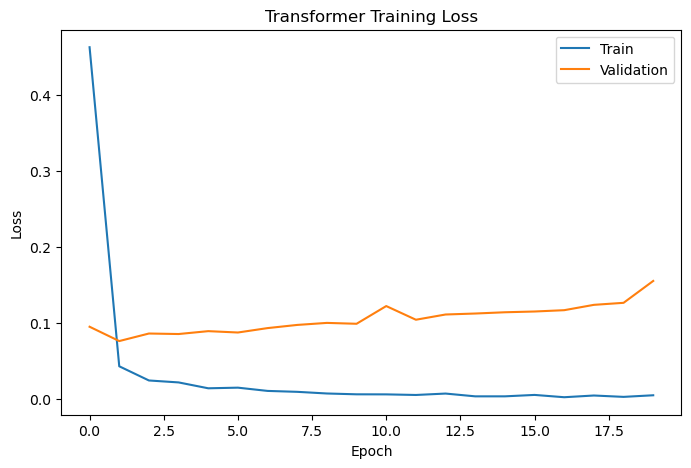

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Transformer Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Transformer Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [7]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\nTransformer Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Healthy",
            "Bacterial Blight",
            "Anthracnose",
            "Fruit Rot"
        ]
    )
)

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step

Transformer Classification Report:

                  precision    recall  f1-score   support

         Healthy       1.00      1.00      1.00       218
Bacterial Blight       1.00      0.95      0.97       150
     Anthracnose       0.97      0.97      0.97       175
       Fruit Rot       0.97      0.99      0.98       301

        accuracy                           0.98       844
       macro avg       0.98      0.98      0.98       844
    weighted avg       0.98      0.98      0.98       844



27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


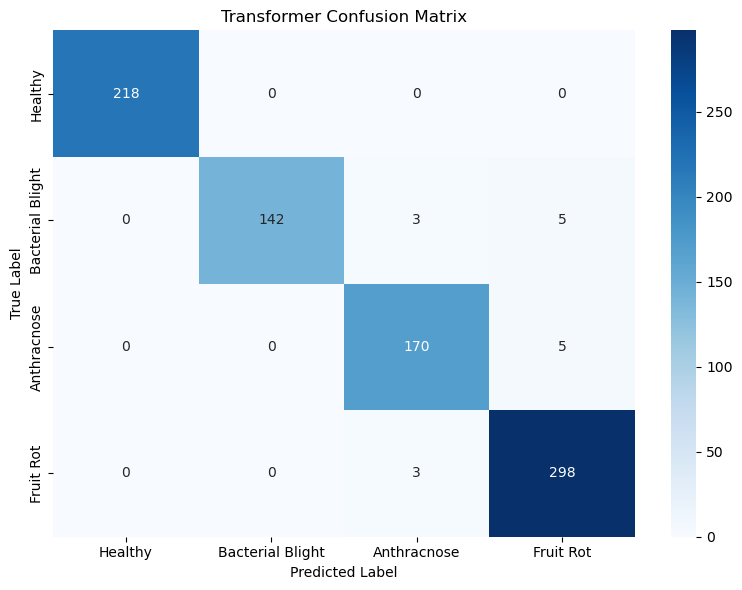

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Predict test data
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Class names
class_names = [
    "Healthy",
    "Bacterial Blight",
    "Anthracnose",
    "Fruit Rot"
]

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Transformer Confusion Matrix")
plt.tight_layout()
plt.show()